Rain files: 10 /content/midas-open_uk-hourly-rain-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_2015.csv … /content/midas-open_uk-hourly-rain-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_2024.csv
Rad  files: 10 /content/midas-open_uk-radiation-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_2015.csv … /content/midas-open_uk-radiation-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_2024.csv
Rain rows: (88558, 2) time: 2015-01-01 00:00:00 → 2024-12-31 23:00:00
Rain missing fraction (prcp_amt): 0.00024842476117346824
Rad rows: (88222, 2) time: 2015-01-01 00:00:00 → 2024-12-31 23:59:00
Rad missing fraction (glbl_irad_amt): 0.00014735553490059168

Annual irradiation (kWh/m2):


,year,kwh_m2
0,2015,882.537222
1,2016,852.443889
2,2017,860.654444
3,2018,963.187222
4,2019,864.317778
5,2020,888.768611
6,2021,893.330278
7,2022,1311.155139
8,2023,1358.867083
9,2024,1253.914167



Annual rainfall (mm):


,year,prcp_amt
0,2015,2130.6
1,2016,1894.5
2,2017,1588.6
3,2018,1443.3
4,2019,2296.8
5,2020,2394.5
6,2021,1745.8
7,2022,1751.0
8,2023,1716.0
9,2024,2131.0



Solar sizing:
Mean panel area (m2): 34.01319257356774
Worst-year panel area (m2): 39.10325801828599 in year 2016
Adopted PV area (rounded up): 40.0 m2

Battery requirement by year (kWh) assuming full on Jan 1:


,year,battery_kwh_min
0,2015,566.678333
1,2016,585.646667
2,2017,552.398333
3,2018,579.613333
4,2019,546.500000
5,2020,590.183333
6,2021,562.603333
7,2022,466.466667
8,2023,453.071667
9,2024,431.964167


Recommended minimum battery (worst year): 590.1833333333334 kWh
Practical rounded recommendation: 600.0 kWh (round to 50 kWh blocks)

Rainwater sizing:
Mean roof area (m2): 126.31690111457813
Worst-year roof area (m2): 163.02509363753816 in year 2018
Adopted collection area (rounded up): 164.0 m2

Tank requirement by year (m3) assuming full on Jan 1:


,year,tank_m3_min
0,2015,0.000000
1,2016,0.000000
2,2017,1.449773
3,2018,29.480333
4,2019,0.964653
5,2020,0.000000
6,2021,15.551467
7,2022,0.000000
8,2023,9.027560
9,2024,0.000000


Recommended minimum tank (worst year): 29.48033333333335 m3
Practical rounded recommendation: 30.0 m3 (round to 5 m3 blocks)


/tmp/ipython-input-348/83390472.py:342: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rad_month_arrays, labels=list(months)[:len(rad_month_arrays)], showfliers=False,


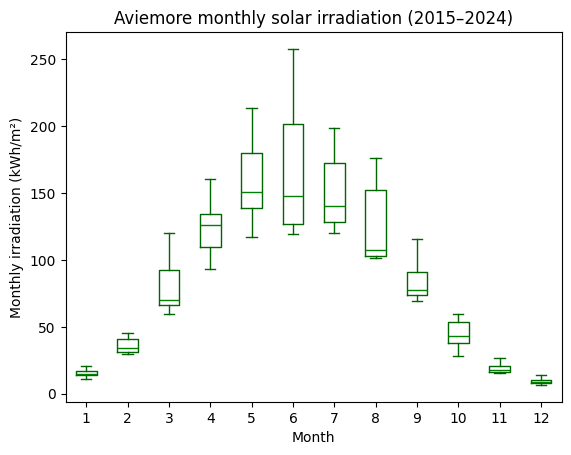

/tmp/ipython-input-348/83390472.py:361: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rain_month_arrays, labels=list(months)[:len(rain_month_arrays)], showfliers=False,


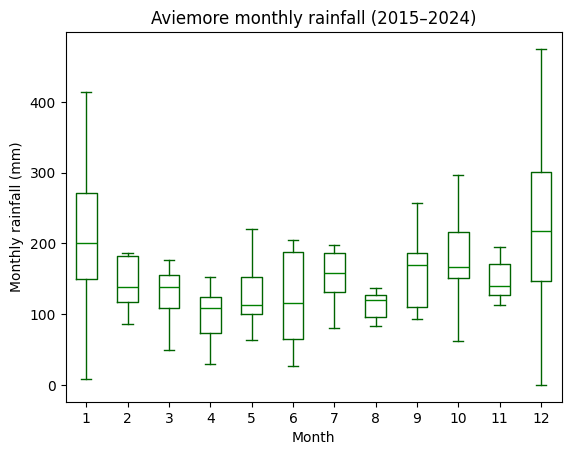

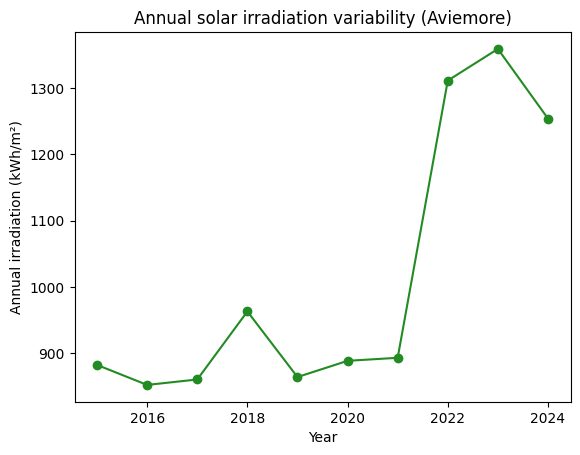

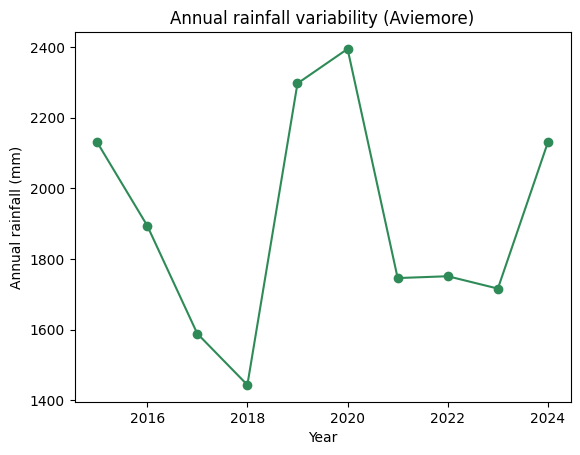

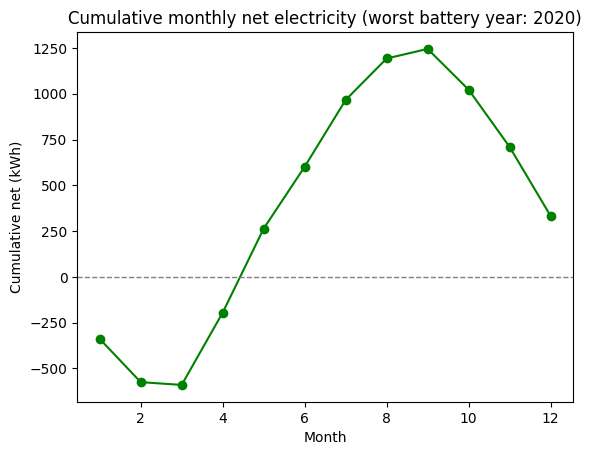

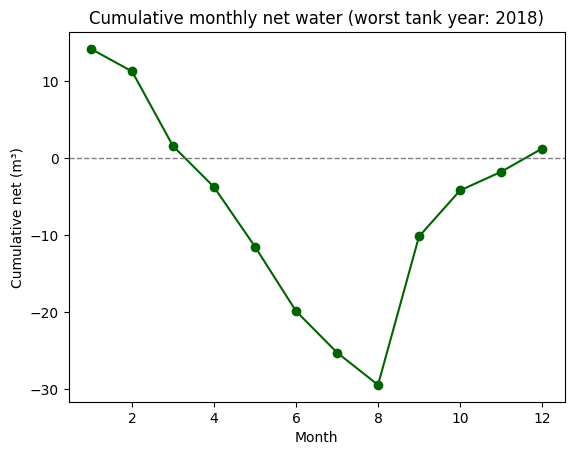

,Metric,Value
0,PV area sized to worst solar year,40 m²
1,"Recommended minimum battery (worst year, full ...",600 kWh
2,Rain catchment area sized to driest year,164 m²
3,"Recommended minimum tank (worst year, full on ...",30 m³


In [4]:
# CP540 Assessment 2 (Aviemore, MIDAS Open) — Solar + Rain self-sufficiency
# Data: hourly rainfall + hourly solar irradiation (global) for 2015–2024

import pandas as pd
import numpy as np
import glob as gb
from pathlib import Path
import matplotlib.pyplot as plt

# -------------------------
# 1) FILE PATHS
# -------------------------

rain_files = sorted(gb.glob("/content/midas-open_uk-hourly-rain-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_20*.csv"))
rad_files  = sorted(gb.glob("/content/midas-open_uk-radiation-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_20*.csv"))

if len(rain_files) > 0:
    print("Rain files:", len(rain_files), rain_files[0], "…", rain_files[-1])
else:
    print("Rain files: No files found matching the pattern. Please ensure files are uploaded to /content/ or update the path.")

if len(rad_files) > 0:
    print("Rad  files:", len(rad_files),  rad_files[0],  "…", rad_files[-1])
else:
    print("Rad  files: No files found matching the pattern. Please ensure files are uploaded to /content/ or update the path.")

# -------------------------
# 2) MIDAS “BADC-CSV” READER
# -------------------------
def read_midas_badc_csv(filepath: str) -> pd.DataFrame:
    """
    MIDAS Open files start with metadata lines and then a line containing exactly: 'data'
    The next line is the true header row.
    This function finds that marker and reads the data block as a normal CSV.
    """
    data_line = None
    with open(filepath, "r", errors="ignore") as f:
        for i, line in enumerate(f):
            if line.strip() == "data":
                data_line = i
                break
    if data_line is None:
        raise ValueError(f"No 'data' marker found in: {filepath}")

    df = pd.read_csv(filepath, skiprows=data_line + 1, na_values=["NA"])
    return df

# -------------------------
# 3) LOAD + CLEAN RAIN
# -------------------------
def load_rain(files) -> pd.DataFrame:
    frames = []
    for fp in files:
        try:
            df = read_midas_badc_csv(fp)

            # Parse time; drop non-time footer rows if any (some MIDAS exports contain trailing text)
            df["ob_end_time"] = pd.to_datetime(df["ob_end_time"], errors="coerce")
            df["prcp_amt"]    = pd.to_numeric(df["prcp_amt"], errors="coerce")

            df = df.dropna(subset=["ob_end_time"])  # remove footer / bad rows
            frames.append(df[["ob_end_time", "prcp_amt"]])
        except Exception as e:
            print(f"Error loading {fp}: {e}")
            continue

    if not frames:
        # Return an empty DataFrame with expected columns if no data was loaded
        return pd.DataFrame(columns=["ob_end_time", "prcp_amt"])

    out = pd.concat(frames, ignore_index=True).sort_values("ob_end_time")
    return out

if len(rain_files) > 0:
    rain = load_rain(rain_files)
    if not rain.empty:
        print("Rain rows:", rain.shape, "time:", rain["ob_end_time"].min(), "→", rain["ob_end_time"].max())
        print("Rain missing fraction (prcp_amt):", rain["prcp_amt"].isna().mean())
    else:
        print("Rain data frame is empty after loading. No valid rain data.")
else:
    print("No rain files found to load. Initializing 'rain' as an empty DataFrame.")
rain = pd.DataFrame(columns=["ob_end_time", "prcp_amt"]) if rain.empty else rain

# -------------------------
# 4) LOAD + CLEAN RADIATION
# -------------------------
def load_rad(files) -> pd.DataFrame:
    frames = []
    for fp in files:
        try:
            df = read_midas_badc_csv(fp)

            df["ob_end_time"]    = pd.to_datetime(df["ob_end_time"], errors="coerce")
            df["glbl_irad_amt"]  = pd.to_numeric(df["glbl_irad_amt"], errors="coerce")  # KJ/m2

            df = df.dropna(subset=["ob_end_time"])
            frames.append(df[["ob_end_time", "glbl_irad_amt"]])
        except Exception as e:
            print(f"Error loading {fp}: {e}")
            continue

    if not frames:
        # Return an empty DataFrame with expected columns if no data was loaded
        return pd.DataFrame(columns=["ob_end_time", "glbl_irad_amt"])

    out = pd.concat(frames, ignore_index=True).sort_values("ob_end_time")
    return out

if len(rad_files) > 0:
    rad = load_rad(rad_files)
    if not rad.empty:
        print("Rad rows:", rad.shape, "time:", rad["ob_end_time"].min(), "→", rad["ob_end_time"].max())
        print("Rad missing fraction (glbl_irad_amt):", rad["glbl_irad_amt"].isna().mean())
    else:
        print("Radiation data frame is empty after loading. No valid radiation data.")
else:
    print("No radiation files found to load. Initializing 'rad' as an empty DataFrame.")
rad = pd.DataFrame(columns=["ob_end_time", "glbl_irad_amt"]) if rad.empty else rad

# -------------------------
# 5) AGGREGATE TO HOURLY, MONTHLY, ANNUAL
# -------------------------
# Radiation sometimes has end times at xx:59 (seen in MIDAS); flooring to hour avoids split bins.
rad2 = pd.DataFrame(columns=['time', 'glbl_irad_amt', 'kwh_m2'])
if not rad.empty and 'ob_end_time' in rad.columns and 'glbl_irad_amt' in rad.columns:
    rad2 = rad.copy()
    rad2["time"] = rad2["ob_end_time"].dt.floor("h")
    rad2 = rad2.drop(columns=["ob_end_time"])
    rad2 = rad2.groupby("time", as_index=False)["glbl_irad_amt"].mean()
    rad2["kwh_m2"] = rad2["glbl_irad_amt"] / 3600.0
else:
    print("Rad DataFrame is empty or missing necessary columns, rad2 initialized as empty.")

rain2 = pd.DataFrame(columns=['time', 'prcp_amt'])
if not rain.empty and 'ob_end_time' in rain.columns and 'prcp_amt' in rain.columns:
    rain2 = rain.copy()
    rain2["time"] = rain2["ob_end_time"].dt.floor("h")
    rain2 = rain2.drop(columns=["ob_end_time"])
    rain2 = rain2.groupby("time", as_index=False)["prcp_amt"].sum()
else:
    print("Rain DataFrame is empty or missing necessary columns, rain2 initialized as empty.")

# Add year/month keys
for df_var in (rad2, rain2):
    if not df_var.empty and 'time' in df_var.columns:
        df_var["year"]  = df_var["time"].dt.year
        df_var["month"] = df_var["time"].dt.month
    else:
        # Ensure 'year' and 'month' columns exist even if empty, to prevent KeyError later
        if 'year' not in df_var.columns:
            df_var['year'] = pd.Series(dtype='int')
        if 'month' not in df_var.columns:
            df_var['month'] = pd.Series(dtype='int')

monthly_rad = pd.DataFrame(columns=["year", "month", "kwh_m2"])
if not rad2.empty and "year" in rad2.columns and "month" in rad2.columns and "kwh_m2" in rad2.columns:
    monthly_rad = rad2.groupby(["year", "month"], as_index=False)["kwh_m2"].sum()
else:
    print("monthly_rad initialized as empty due to empty rad2 or missing columns.")

monthly_rain = pd.DataFrame(columns=["year", "month", "prcp_amt"])
if not rain2.empty and "year" in rain2.columns and "month" in rain2.columns and "prcp_amt" in rain2.columns:
    monthly_rain = rain2.groupby(["year", "month"], as_index=False)["prcp_amt"].sum()
else:
    print("monthly_rain initialized as empty due to empty rain2 or missing columns.")

annual_rad = pd.DataFrame(columns=["year", "kwh_m2"])
if not monthly_rad.empty and "year" in monthly_rad.columns and "kwh_m2" in monthly_rad.columns:
    annual_rad = monthly_rad.groupby("year", as_index=False)["kwh_m2"].sum()
else:
    print("annual_rad initialized as empty due to empty monthly_rad or missing columns.")

annual_rain = pd.DataFrame(columns=["year", "prcp_amt"])
if not monthly_rain.empty and "year" in monthly_rain.columns and "prcp_amt" in monthly_rain.columns:
    annual_rain = monthly_rain.groupby("year", as_index=False)["prcp_amt"].sum()
else:
    print("annual_rain initialized as empty due to empty monthly_rain or missing columns.")

print("\nAnnual irradiation (kWh/m2):")
display(annual_rad)

print("\nAnnual rainfall (mm):")
display(annual_rain)

# -------------------------
# 6) SYSTEM SIZING ASSUMPTIONS
# -------------------------
E_elec_year = 5000.0     # kWh/year household electricity demand
V_water_year = 200.0     # m3/year household water demand
eta_pv = 0.15            # PV conversion efficiency (given in brief)
runoff = 0.85            # roof runoff coefficient (typical assumption; justify in notes)

# -------------------------
# 7) SOLAR PANEL AREA (YEAR-TO-YEAR VARIATION)
# -------------------------
A_pv_rounded = 0 # Initialize with a default value
if not annual_rad.empty and "kwh_m2" in annual_rad.columns and not annual_rad["kwh_m2"].eq(0).all():
    annual_rad["elec_kwh_per_m2"] = annual_rad["kwh_m2"] * eta_pv
    # Handle potential division by zero or very small numbers, resulting in inf
    annual_rad["panel_area_m2"]   = E_elec_year / annual_rad["elec_kwh_per_m2"]
    annual_rad.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Recommend sizing based on worst (lowest irradiation) year
    if not annual_rad["panel_area_m2"].dropna().empty:
        worst_solar = annual_rad.loc[annual_rad["panel_area_m2"].idxmax()]

        print("\nSolar sizing:")
        print("Mean panel area (m2):", annual_rad["panel_area_m2"].mean())
        print("Worst-year panel area (m2):", float(worst_solar["panel_area_m2"]), "in year", int(worst_solar["year"]))

        A_pv = float(worst_solar["panel_area_m2"])  # adopt worst-year design area
        A_pv_rounded = np.ceil(A_pv)                # practical rounding to whole m2
        print("Adopted PV area (rounded up):", A_pv_rounded, "m2")
    else:
        print("\nSolar sizing: Not enough valid data for meaningful solar panel area calculation.")
else:
    print("\nSolar sizing: Annual radiation DataFrame is empty or contains no valid `kwh_m2` data. Cannot calculate solar panel area.")

# -------------------------
# 8) ELECTRICITY STORAGE (SEASONAL)
# -------------------------
monthly = pd.DataFrame(columns=["year", "month", "pv_gen_kwh", "demand_kwh", "net_kwh"])
if not monthly_rad.empty and not monthly_rain.empty:
    monthly = monthly_rad.merge(monthly_rain, on=["year", "month"], how="inner")
    if not monthly.empty:
        monthly["pv_gen_kwh"] = monthly["kwh_m2"] * eta_pv * A_pv_rounded
        monthly["demand_kwh"] = E_elec_year / 12.0
        monthly["net_kwh"]    = monthly["pv_gen_kwh"] - monthly["demand_kwh"]
    else:
        print("Monthly merge for electricity storage resulted in an empty DataFrame.")
else:
    print("Monthly radiation or rain DataFrame is empty. Cannot calculate electricity storage.")

def min_storage_if_full_at_year_start(net_monthly: pd.Series) -> float:
    """
    Computes the minimum battery capacity required to avoid shortage during the year,
    assuming the battery starts 'full' on Jan 1 and any surplus can be curtailed/spilled.

    Logic:
    State(t) = C + cumulative_sum(net)
    Need State(t) >= 0 for all t => C >= -min(cumulative_sum(net))
    """
    if net_monthly.empty:
        return 0.0
    cum = net_monthly.cumsum()
    return max(0.0, -float(cum.min()))

battery_by_year = pd.DataFrame(columns=["year", "battery_kwh_min"])
if not monthly.empty and 'net_kwh' in monthly.columns:
    batt_data = []
    for y, dfy in monthly.sort_values(["year", "month"]).groupby("year"):
        if not dfy['net_kwh'].empty:
            C = min_storage_if_full_at_year_start(dfy["net_kwh"])
            batt_data.append((y, C))
    if batt_data:
        battery_by_year = pd.DataFrame(batt_data, columns=["year", "battery_kwh_min"])
        print("\nBattery requirement by year (kWh) assuming full on Jan 1:")
        display(battery_by_year)

battery_recommended = 0.0 # Default value
if not battery_by_year.empty and "battery_kwh_min" in battery_by_year.columns:
    battery_recommended = battery_by_year["battery_kwh_min"].max()
    print("Recommended minimum battery (worst year):", battery_recommended, "kWh")
    print("Practical rounded recommendation:", np.ceil(battery_recommended/50)*50, "kWh (round to 50 kWh blocks)")
else:
    print("\nBattery requirement: Not enough data to calculate seasonal electricity storage.")


# -------------------------
# 9) RAINWATER COLLECTION AREA (YEAR-TO-YEAR VARIATION)
# -------------------------
A_roof_rounded = 0 # Initialize with a default value
if not annual_rain.empty and "prcp_amt" in annual_rain.columns and not annual_rain["prcp_amt"].eq(0).all():
    annual_rain["m3_per_m2_year"] = annual_rain["prcp_amt"] * 0.001 * runoff
    # Handle potential division by zero or very small numbers, resulting in inf
    annual_rain["roof_area_m2"]   = V_water_year / annual_rain["m3_per_m2_year"]
    annual_rain.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Recommend sizing based on worst (lowest irradiation) year
    if not annual_rain["roof_area_m2"].dropna().empty:
        worst_rain = annual_rain.loc[annual_rain["roof_area_m2"].idxmax()]
        print("\nRainwater sizing:")
        print("Mean roof area (m2):", annual_rain["roof_area_m2"].mean())
        print("Worst-year roof area (m2):", float(worst_rain["roof_area_m2"]), "in year", int(worst_rain["year"]))

        A_roof = float(worst_rain["roof_area_m2"])
        A_roof_rounded = np.ceil(A_roof)
        print("Adopted collection area (rounded up):", A_roof_rounded, "m2")
    else:
        print("\nRainwater sizing: Not enough valid data for meaningful rainwater collection area calculation.")
else:
    print("\nRainwater sizing: Annual rainfall DataFrame is empty or contains no valid `prcp_amt` data. Cannot calculate rainwater collection area.")

# -------------------------
# 10) WATER STORAGE (SEASONAL)
# -------------------------
# Ensure 'monthly' DataFrame has necessary columns even if initially empty from previous steps
required_cols_monthly_water = ["year", "month", "prcp_amt", "water_collected_m3", "water_demand_m3", "net_water_m3"]
for col in required_cols_monthly_water:
    if col not in monthly.columns:
        monthly[col] = pd.Series(dtype='float') # Use float for numeric cols

if not monthly.empty and 'prcp_amt' in monthly.columns:
    monthly["water_collected_m3"] = monthly["prcp_amt"] * 0.001 * A_roof_rounded * runoff
    monthly["water_demand_m3"]    = V_water_year / 12.0
    monthly["net_water_m3"]       = monthly["water_collected_m3"] - monthly["water_demand_m3"]
else:
    print("Monthly DataFrame is empty or missing 'prcp_amt'. Cannot calculate water balance for storage.")

tank_by_year = pd.DataFrame(columns=["year", "tank_m3_min"])
if not monthly.empty and 'net_water_m3' in monthly.columns:
    tank_data = []
    for y, dfy in monthly.sort_values(["year", "month"]).groupby("year"):
        if not dfy['net_water_m3'].empty:
            Cw = min_storage_if_full_at_year_start(dfy["net_water_m3"])
            tank_data.append((y, Cw))
    if tank_data:
        tank_by_year = pd.DataFrame(tank_data, columns=["year", "tank_m3_min"])
        print("\nTank requirement by year (m3) assuming full on Jan 1:")
        display(tank_by_year)

tank_recommended = 0.0 # Default value
if not tank_by_year.empty and "tank_m3_min" in tank_by_year.columns:
    tank_recommended = tank_by_year["tank_m3_min"].max()
    print("Recommended minimum tank (worst year):", tank_recommended, "m3")
    print("Practical rounded recommendation:", np.ceil(tank_recommended/5)*5, "m3 (round to 5 m3 blocks)")
else:
    print("\nTank requirement: Not enough data to calculate seasonal water storage.")

# -------------------------
# 11) FIGURES FOR SLIDES
# -------------------------
# A) Monthly irradiation distribution across years (boxplot-like via grouped arrays)
months = range(1, 13)
if not monthly_rad.empty and "month" in monthly_rad.columns and "kwh_m2" in monthly_rad.columns:
    rad_month_arrays = [monthly_rad.loc[monthly_rad["month"]==m, "kwh_m2"].values for m in months]
    rad_month_arrays = [arr for arr in rad_month_arrays if arr.size > 0] # Filter out empty arrays

    if rad_month_arrays:
        plt.figure()
        plt.boxplot(rad_month_arrays, labels=list(months)[:len(rad_month_arrays)], showfliers=False,
                    boxprops=dict(color='darkgreen'), medianprops=dict(color='green'),
                    whiskerprops=dict(color='darkgreen'), capprops=dict(color='darkgreen'))
        plt.xlabel("Month")
        plt.ylabel("Monthly irradiation (kWh/m²)")
        plt.title("Aviemore monthly solar irradiation (2015–2024)")
        plt.show()
    else:
        print("Not enough valid data to plot monthly solar irradiation boxplot.")
else:
    print("Monthly radiation DataFrame is empty or missing required columns. Cannot plot monthly solar irradiation boxplot.")

# B) Monthly rainfall distribution across years
if not monthly_rain.empty and "month" in monthly_rain.columns and "prcp_amt" in monthly_rain.columns:
    rain_month_arrays = [monthly_rain.loc[monthly_rain["month"]==m, "prcp_amt"].values for m in months]
    rain_month_arrays = [arr for arr in rain_month_arrays if arr.size > 0] # Filter out empty arrays

    if rain_month_arrays:
        plt.figure()
        plt.boxplot(rain_month_arrays, labels=list(months)[:len(rain_month_arrays)], showfliers=False,
                    boxprops=dict(color='darkgreen'), medianprops=dict(color='green'),
                    whiskerprops=dict(color='darkgreen'), capprops=dict(color='darkgreen'))
        plt.xlabel("Month")
        plt.ylabel("Monthly rainfall (mm)")
        plt.title("Aviemore monthly rainfall (2015–2024)")
        plt.show()
    else:
        print("Not enough valid data to plot monthly rainfall boxplot.")
else:
    print("Monthly rainfall DataFrame is empty or missing required columns. Cannot plot monthly rainfall boxplot.")

# C) Annual variability plots
if not annual_rad.empty and "year" in annual_rad.columns and "kwh_m2" in annual_rad.columns:
    plt.figure()
    plt.plot(annual_rad["year"], annual_rad["kwh_m2"], marker="o", color='forestgreen')
    plt.xlabel("Year")
    plt.ylabel("Annual irradiation (kWh/m²)")
    plt.title("Annual solar irradiation variability (Aviemore)")
    plt.show()
else:
    print("Annual radiation DataFrame is empty or missing required columns. Cannot plot annual solar irradiation variability.")

if not annual_rain.empty and "year" in annual_rain.columns and "prcp_amt" in annual_rain.columns:
    plt.figure()
    plt.plot(annual_rain["year"], annual_rain["prcp_amt"], marker="o", color='seagreen')
    plt.xlabel("Year")
    plt.ylabel("Annual rainfall (mm)")
    plt.title("Annual rainfall variability (Aviemore)")
    plt.show()
else:
    print("Annual rainfall DataFrame is empty or missing required columns. Cannot plot annual rainfall variability.")

# D) Example worst-year seasonal storage curves (electricity + water)
worst_batt_year = None
if not battery_by_year.empty and "battery_kwh_min" in battery_by_year.columns:
    worst_batt_year = int(battery_by_year.loc[battery_by_year["battery_kwh_min"].idxmax(), "year"])
else:
    print("Battery by year DataFrame is empty or missing 'battery_kwh_min'. Cannot determine worst battery year for plotting.")

worst_tank_year = None
if not tank_by_year.empty and "tank_m3_min" in tank_by_year.columns:
    worst_tank_year = int(tank_by_year.loc[tank_by_year["tank_m3_min"].idxmax(), "year"])
else:
    print("Tank by year DataFrame is empty or missing 'tank_m3_min'. Cannot determine worst tank year for plotting.")

def plot_cumulative_balance(df, value_col, title, ylab, plot_color='green'):
    if df.empty or value_col not in df.columns or df[value_col].isnull().all():
        print(f"Skipping plot '{title}' due to empty DataFrame, missing column '{value_col}', or all null values.")
        return
    d = df.sort_values(["month"]).copy()
    d["cum"] = d[value_col].cumsum()
    plt.figure()
    plt.plot(d["month"], d["cum"], marker="o", color=plot_color)
    plt.xlabel("Month")
    plt.ylabel(ylab)
    plt.title(title)
    plt.axhline(0, linewidth=1, color='gray', linestyle='--') # Add gray dashed line for zero
    plt.show()

if worst_batt_year is not None and not monthly.empty and "year" in monthly.columns and "net_kwh" in monthly.columns:
    plot_cumulative_balance(monthly[monthly["year"]==worst_batt_year], "net_kwh",
                            f"Cumulative monthly net electricity (worst battery year: {worst_batt_year})",
                            "Cumulative net (kWh)", plot_color='green')
else:
    print("Cannot plot cumulative net electricity due to missing worst battery year or incomplete monthly data.")

if worst_tank_year is not None and not monthly.empty and "year" in monthly.columns and "net_water_m3" in monthly.columns:
    plot_cumulative_balance(monthly[monthly["year"]==worst_tank_year], "net_water_m3",
                            f"Cumulative monthly net water (worst tank year: {worst_tank_year})",
                            "Cumulative net (m³)", plot_color='darkgreen')
else:
    print("Cannot plot cumulative net water due to missing worst tank year or incomplete monthly data.")

# E) Summary table for final slide
summary = pd.DataFrame({
    "Metric": [
        "PV area sized to worst solar year",
        "Recommended minimum battery (worst year, full on Jan 1)",
        "Rain catchment area sized to driest year",
        "Recommended minimum tank (worst year, full on Jan 1)"
    ],
    "Value": [
        f"{A_pv_rounded:.0f} m²" if A_pv_rounded is not np.inf else "N/A",
        f"{np.ceil(battery_recommended/50)*50:.0f} kWh",
        f"{A_roof_rounded:.0f} m²" if A_roof_rounded is not np.inf else "N/A",
        f"{np.ceil(tank_recommended/5)*5:.0f} m³"
    ]
})
display(summary)

In [5]:
# F) Panel area per year
print("\nSolar panel area per year (m2):")
if not annual_rad.empty and "year" in annual_rad.columns and "panel_area_m2" in annual_rad.columns:
    display(annual_rad[["year", "panel_area_m2"]])
else:
    print("Annual radiation DataFrame is empty or missing necessary columns for panel area calculation.")


Solar panel area per year (m2):


,year,panel_area_m2
0,2015,37.769889
1,2016,39.103258
2,2017,38.730217
3,2018,34.607325
4,2019,38.566062
5,2020,37.505075
6,2021,37.313560
7,2022,25.422875
8,2023,24.530238
9,2024,26.583425


# Task
Update the storage capacity calculation logic for both electricity batteries and water tanks. The existing `min_storage_if_full_at_year_start` function, which assumes a full state at the beginning of the year, needs to be replaced. Instead, calculate the `min_storage_capacity` by determining the difference between the maximum and minimum cumulative sum of monthly net energy/water. Apply this new `min_storage_capacity` function to both the battery and water tank sizing sections. Finally, adjust all relevant print statements and the summary table to reflect that the recommendation is for the required storage capacity, not an initial charge or an assumption of a full state at year start.

```python
# CP540 Assessment 2 (Aviemore, MIDAS Open) — Solar + Rain self-sufficiency
# Data: hourly rainfall + hourly solar irradiation (global) for 2015–2024

import pandas as pd
import numpy as np
import glob as gb
from pathlib import Path
import matplotlib.pyplot as plt

# -------------------------
# 1) FILE PATHS
# -------------------------

rain_files = sorted(gb.glob("/content/midas-open_uk-hourly-rain-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_20*.csv"))
rad_files  = sorted(gb.glob("/content/midas-open_uk-radiation-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_20*.csv"))

if len(rain_files) > 0:
    print("Rain files:", len(rain_files), rain_files[0], "…", rain_files[-1])
else:
    print("Rain files: No files found matching the pattern. Please ensure files are uploaded to /content/ or update the path.")

if len(rad_files) > 0:
    print("Rad  files:", len(rad_files),  rad_files[0],  "…", rad_files[-1])
else:
    print("Rad  files: No files found matching the pattern. Please ensure files are uploaded to /content/ or update the path.")

# -------------------------
# 2) MIDAS “BADC-CSV” READER
# -------------------------
def read_midas_badc_csv(filepath: str) -> pd.DataFrame:
    """
    MIDAS Open files start with metadata lines and then a line containing exactly: 'data'
    The next line is the true header row.
    This function finds that marker and reads the data block as a normal CSV.
    """
    data_line = None
    with open(filepath, "r", errors="ignore") as f:
        for i, line in enumerate(f):
            if line.strip() == "data":
                data_line = i
                break
    if data_line is None:
        raise ValueError(f"No 'data' marker found in: {filepath}")

    df = pd.read_csv(filepath, skiprows=data_line + 1, na_values=["NA"])
    return df

# -------------------------
# 3) LOAD + CLEAN RAIN
# -------------------------
def load_rain(files) -> pd.DataFrame:
    frames = []
    for fp in files:
        try:
            df = read_midas_badc_csv(fp)

            # Parse time; drop non-time footer rows if any (some MIDAS exports contain trailing text)
            df["ob_end_time"] = pd.to_datetime(df["ob_end_time"], errors="coerce")
            df["prcp_amt"]    = pd.to_numeric(df["prcp_amt"], errors="coerce")

            df = df.dropna(subset=["ob_end_time"])  # remove footer / bad rows
            frames.append(df[["ob_end_time", "prcp_amt"]])
        except Exception as e:
            print(f"Error loading {fp}: {e}")
            continue

    if not frames:
        # Return an empty DataFrame with expected columns if no data was loaded
        return pd.DataFrame(columns=["ob_end_time", "prcp_amt"])

    out = pd.concat(frames, ignore_index=True).sort_values("ob_end_time")
    return out

if len(rain_files) > 0:
    rain = load_rain(rain_files)
    if not rain.empty:
        print("Rain rows:", rain.shape, "time:", rain["ob_end_time"].min(), "→", rain["ob_end_time"].max())
        print("Rain missing fraction (prcp_amt):", rain["prcp_amt"].isna().mean())
    else:
        print("Rain data frame is empty after loading. No valid rain data.")
else:
    print("No rain files found to load. Initializing 'rain' as an empty DataFrame.")
rain = pd.DataFrame(columns=["ob_end_time", "prcp_amt"]) if rain.empty else rain

# -------------------------
# 4) LOAD + CLEAN RADIATION
# -------------------------
def load_rad(files) -> pd.DataFrame:
    frames = []
    for fp in files:
        try:
            df = read_midas_badc_csv(fp)

            df["ob_end_time"]    = pd.to_datetime(df["ob_end_time"], errors="coerce")
            df["glbl_irad_amt"]  = pd.to_numeric(df["glbl_irad_amt"], errors="coerce")  # KJ/m2

            df = df.dropna(subset=["ob_end_time"])
            frames.append(df[["ob_end_time", "glbl_irad_amt"]])
        except Exception as e:
            print(f"Error loading {fp}: {e}")
            continue

    if not frames:
        # Return an empty DataFrame with expected columns if no data was loaded
        return pd.DataFrame(columns=["ob_end_time", "glbl_irad_amt"])

    out = pd.concat(frames, ignore_index=True).sort_values("ob_end_time")
    return out

if len(rad_files) > 0:
    rad = load_rad(rad_files)
    if not rad.empty:
        print("Rad rows:", rad.shape, "time:", rad["ob_end_time"].min(), "→", rad["ob_end_time"].max())
        print("Rad missing fraction (glbl_irad_amt):", rad["glbl_irad_amt"].isna().mean())
    else:
        print("Radiation data frame is empty after loading. No valid radiation data.")
else:
    print("No radiation files found to load. Initializing 'rad' as an empty DataFrame.")
rad = pd.DataFrame(columns=["ob_end_time", "glbl_irad_amt"]) if rad.empty else rad

# -------------------------
# 5) AGGREGATE TO HOURLY, MONTHLY, ANNUAL
# -------------------------
# Radiation sometimes has end times at xx:59 (seen in MIDAS); flooring to hour avoids split bins.
rad2 = pd.DataFrame(columns=['time', 'glbl_irad_amt', 'kwh_m2'])
if not rad.empty and 'ob_end_time' in rad.columns and 'glbl_irad_amt' in rad.columns:
    rad2 = rad.copy()
    rad2["time"] = rad2["ob_end_time"].dt.floor("h")
    rad2 = rad2.drop(columns=["ob_end_time"])
    rad2 = rad2.groupby("time", as_index=False)["glbl_irad_amt"].mean()
    rad2["kwh_m2"] = rad2["glbl_irad_amt"] / 3600.0
else:
    print("Rad DataFrame is empty or missing necessary columns, rad2 initialized as empty.")

rain2 = pd.DataFrame(columns=['time', 'prcp_amt'])
if not rain.empty and 'ob_end_time' in rain.columns and 'prcp_amt' in rain.columns:
    rain2 = rain.copy()
    rain2["time"] = rain2["ob_end_time"].dt.floor("h")
    rain2 = rain2.drop(columns=["ob_end_time"])
    rain2 = rain2.groupby("time", as_index=False)["prcp_amt"].sum()
else:
    print("Rain DataFrame is empty or missing necessary columns, rain2 initialized as empty.")

# Add year/month keys
for df_var in (rad2, rain2):
    if not df_var.empty and 'time' in df_var.columns:
        df_var["year"]  = df_var["time"].dt.year
        df_var["month"] = df_var["time"].dt.month
    else:
        # Ensure 'year' and 'month' columns exist even if empty, to prevent KeyError later
        if 'year' not in df_var.columns:
            df_var['year'] = pd.Series(dtype='int')
        if 'month' not in df_var.columns:
            df_var['month'] = pd.Series(dtype='int')

monthly_rad = pd.DataFrame(columns=["year", "month", "kwh_m2"])
if not rad2.empty and "year" in rad2.columns and "month" in rad2.columns and "kwh_m2" in rad2.columns:
    monthly_rad = rad2.groupby(["year", "month"], as_index=False)["kwh_m2"].sum()
else:
    print("monthly_rad initialized as empty due to empty rad2 or missing columns.")

monthly_rain = pd.DataFrame(columns=["year", "month", "prcp_amt"])
if not rain2.empty and "year" in rain2.columns and "month" in rain2.columns and "prcp_amt" in rain2.columns:
    monthly_rain = rain2.groupby(["year", "month"], as_index=False)["prcp_amt"].sum()
else:
    print("monthly_rain initialized as empty due to empty rain2 or missing columns.")

annual_rad = pd.DataFrame(columns=["year", "kwh_m2"])
if not monthly_rad.empty and "year" in monthly_rad.columns and "kwh_m2" in monthly_rad.columns:
    annual_rad = monthly_rad.groupby("year", as_index=False)["kwh_m2"].sum()
else:
    print("annual_rad initialized as empty due to empty monthly_rad or missing columns.")

annual_rain = pd.DataFrame(columns=["year", "prcp_amt"])
if not monthly_rain.empty and "year" in monthly_rain.columns and "prcp_amt" in monthly_rain.columns:
    annual_rain = monthly_rain.groupby("year", as_index=False)["prcp_amt"].sum()
else:
    print("annual_rain initialized as empty due to empty monthly_rain or missing columns.")

print("\nAnnual irradiation (kWh/m2):")
display(annual_rad)

print("\nAnnual rainfall (mm):")
display(annual_rain)

# -------------------------
# 6) SYSTEM SIZING ASSUMPTIONS
# -------------------------
E_elec_year = 5000.0     # kWh/year household electricity demand
V_water_year = 200.0     # m3/year household water demand
eta_pv = 0.15            # PV conversion efficiency (given in brief)
runoff = 0.85            # roof runoff coefficient (typical assumption; justify in notes)

# -------------------------
# 7) SOLAR PANEL AREA (YEAR-TO-YEAR VARIATION)
# -------------------------
A_pv_rounded = 0 # Initialize with a default value
if not annual_rad.empty and "kwh_m2" in annual_rad.columns and not annual_rad["kwh_m2"].eq(0).all():
    annual_rad["elec_kwh_per_m2"] = annual_rad["kwh_m2"] * eta_pv
    # Handle potential division by zero or very small numbers, resulting in inf
    annual_rad["panel_area_m2"]   = E_elec_year / annual_rad["elec_kwh_per_m2"]
    annual_rad.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Recommend sizing based on worst (lowest irradiation) year
    if not annual_rad["panel_area_m2"].dropna().empty:
        worst_solar = annual_rad.loc[annual_rad["panel_area_m2"].idxmax()]

        print("\nSolar sizing:")
        print("Mean panel area (m2):", annual_rad["panel_area_m2"].mean())
        print("Worst-year panel area (m2):", float(worst_solar["panel_area_m2"]), "in year", int(worst_solar["year"]))

        A_pv = float(worst_solar["panel_area_m2"])  # adopt worst-year design area
        A_pv_rounded = np.ceil(A_pv)                # practical rounding to whole m2
        print("Adopted PV area (rounded up):", A_pv_rounded, "m2")
    else:
        print("\nSolar sizing: Not enough valid data for meaningful solar panel area calculation.")
else:
    print("\nSolar sizing: Annual radiation DataFrame is empty or contains no valid `kwh_m2` data. Cannot calculate solar panel area.")

# -------------------------
# 8) ELECTRICITY STORAGE (SEASONAL)
# -------------------------
monthly = pd.DataFrame(columns=["year", "month", "pv_gen_kwh", "demand_kwh", "net_kwh"])
if not monthly_rad.empty and not monthly_rain.empty:
    monthly = monthly_rad.merge(monthly_rain, on=["year", "month"], how="inner")
    if not monthly.empty:
        monthly["pv_gen_kwh"] = monthly["kwh_m2"] * eta_pv * A_pv_rounded
        monthly["demand_kwh"] = E_elec_year / 12.0
        monthly["net_kwh"]    = monthly["pv_gen_kwh"] - monthly["demand_kwh"]
    else:
        print("Monthly merge for electricity storage resulted in an empty DataFrame.")
else:
    print("Monthly radiation or rain DataFrame is empty. Cannot calculate electricity storage.")

def min_storage_capacity(net_monthly: pd.Series) -> float:
    """
    Computes the minimum storage capacity required to meet all demand,
    regardless of the initial state, assuming surplus can be curtailed/spilled.
    This is equivalent to the difference between the maximum and minimum
    cumulative sum of net energy/water over the period.
    """
    if net_monthly.empty:
        return 0.0
    cum = net_monthly.cumsum()
    return float(cum.max() - cum.min())

battery_by_year = pd.DataFrame(columns=["year", "battery_kwh_min"])
if not monthly.empty and 'net_kwh' in monthly.columns:
    batt_data = []
    for y, dfy in monthly.sort_values(["year", "month"]).groupby("year"):
        if not dfy['net_kwh'].empty:
            # Use the new min_storage_capacity function
            C = min_storage_capacity(dfy["net_kwh"])
            batt_data.append((y, C))
    if batt_data:
        battery_by_year = pd.DataFrame(batt_data, columns=["year", "battery_kwh_min"])
        print("\nBattery capacity requirement by year (kWh):") # Updated print statement
        display(battery_by_year)

battery_recommended = 0.0 # Default value
if not battery_by_year.empty and "battery_kwh_min" in battery_by_year.columns:
    battery_recommended = battery_by_year["battery_kwh_min"].max()
    print("Recommended minimum battery capacity (worst year):", battery_recommended, "kWh") # Updated print statement
    print("Practical rounded recommendation:", np.ceil(battery_recommended/50)*50, "kWh (round to 50 kWh blocks)")
else:
    print("\nBattery requirement: Not enough data to calculate seasonal electricity storage.")


# -------------------------
# 9) RAINWATER COLLECTION AREA (YEAR-TO-YEAR VARIATION)
# -------------------------
A_roof_rounded = 0 # Initialize with a default value
if not annual_rain.empty and "prcp_amt" in annual_rain.columns and not annual_rain["prcp_amt"].eq(0).all():
    annual_rain["m3_per_m2_year"] = annual_rain["prcp_amt"] * 0.001 * runoff
    # Handle potential division by zero or very small numbers, resulting in inf
    annual_rain["roof_area_m2"]   = V_water_year / annual_rain["m3_per_m2_year"]
    annual_rain.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Recommend sizing based on worst (lowest irradiation) year
    if not annual_rain["roof_area_m2"].dropna().empty:
        worst_rain = annual_rain.loc[annual_rain["roof_area_m2"].idxmax()]
        print("\nRainwater sizing:")
        print("Mean roof area (m2):", annual_rain["roof_area_m2"].mean())
        print("Worst-year roof area (m2):", float(worst_rain["roof_area_m2"]), "in year", int(worst_rain["year"]))

        A_roof = float(worst_rain["roof_area_m2"])
        A_roof_rounded = np.ceil(A_roof)
        print("Adopted collection area (rounded up):", A_roof_rounded, "m2")
    else:
        print("\nRainwater sizing: Not enough valid data for meaningful rainwater collection area calculation.")
else:
    print("\nRainwater sizing: Annual rainfall DataFrame is empty or contains no valid `prcp_amt` data. Cannot calculate rainwater collection area.")

# -------------------------
# 10) WATER STORAGE (SEASONAL)
# -------------------------
# Ensure 'monthly' DataFrame has necessary columns even if initially empty from previous steps
required_cols_monthly_water = ["year", "month", "prcp_amt", "water_collected_m3", "water_demand_m3", "net_water_m3"]
for col in required_cols_monthly_water:
    if col not in monthly.columns:
        monthly[col] = pd.Series(dtype='float') # Use float for numeric cols

if not monthly.empty and 'prcp_amt' in monthly.columns:
    monthly["water_collected_m3"] = monthly["prcp_amt"] * 0.001 * A_roof_rounded * runoff
    monthly["water_demand_m3"]    = V_water_year / 12.0
    monthly["net_water_m3"]       = monthly["water_collected_m3"] - monthly["water_demand_m3"]
else:
    print("Monthly DataFrame is empty or missing 'prcp_amt'. Cannot calculate water balance for storage.")

tank_by_year = pd.DataFrame(columns=["year", "tank_m3_min"])
if not monthly.empty and 'net_water_m3' in monthly.columns:
    tank_data = []
    for y, dfy in monthly.sort_values(["year", "month"]).groupby("year"):
        if not dfy['net_water_m3'].empty:
            # Use the new min_storage_capacity function
            Cw = min_storage_capacity(dfy["net_water_m3"])
            tank_data.append((y, Cw))
    if tank_data:
        tank_by_year = pd.DataFrame(tank_data, columns=["year", "tank_m3_min"])
        print("\nTank capacity requirement by year (m3):") # Updated print statement
        display(tank_by_year)

tank_recommended = 0.0 # Default value
if not tank_by_year.empty and "tank_m3_min" in tank_by_year.columns:
    tank_recommended = tank_by_year["tank_m3_min"].max()
    print("Recommended minimum tank capacity (worst year):", tank_recommended, "m3") # Updated print statement
    print("Practical rounded recommendation:", np.ceil(tank_recommended/5)*5, "m3 (round to 5 m3 blocks)")
else:
    print("\nTank requirement: Not enough data to calculate seasonal water storage.")

# -------------------------
# 11) FIGURES FOR SLIDES
# -------------------------
# A) Monthly irradiation distribution across years (boxplot-like via grouped arrays)
months = range(1, 13)
if not monthly_rad.empty and "month" in monthly_rad.columns and "kwh_m2" in monthly_rad.columns:
    rad_month_arrays = [monthly_rad.loc[monthly_rad["month"]==m, "kwh_m2"].values for m in months]
    rad_month_arrays = [arr for arr in rad_month_arrays if arr.size > 0] # Filter out empty arrays

    if rad_month_arrays:
        plt.figure()
        plt.boxplot(rad_month_arrays, labels=list(months)[:len(rad_month_arrays)], showfliers=False,
                    boxprops=dict(color='darkgreen'), medianprops=dict(color='green'),
                    whiskerprops=dict(color='darkgreen'), capprops=dict(color='darkgreen'))
        plt.xlabel("Month")
        plt.ylabel("Monthly irradiation (kWh/m²)")
        plt.title("Aviemore monthly solar irradiation (2015–2024)")
        plt.show()
    else:
        print("Not enough valid data to plot monthly solar irradiation boxplot.")
else:
    print("Monthly radiation DataFrame is empty or missing required columns. Cannot plot monthly solar irradiation boxplot.")

# B) Monthly rainfall distribution across years
if not monthly_rain.empty and "month" in monthly_rain.columns and "prcp_amt" in monthly_rain.columns:
    rain_month_arrays = [monthly_rain.loc[monthly_rain["month"]==m, "prcp_amt"].values for m in months]
    rain_month_arrays = [arr for arr in rain_month_arrays if arr.size > 0] # Filter out empty arrays

    if rain_month_arrays:
        plt.figure()
        plt.boxplot(rain_month_arrays, labels=list(months)[:len(rad_month_arrays)], showfliers=False,
                    boxprops=dict(color='darkgreen'), medianprops=dict(color='green'),
                    whiskerprops=dict(color='darkgreen'), capprops=dict(color='darkgreen'))
        plt.xlabel("Month")
        plt.ylabel("Monthly rainfall (mm)")
        plt.title("Aviemore monthly rainfall (2015–2024)")
        plt.show()
    else:
        print("Not enough valid data to plot monthly rainfall boxplot.")
else:
    print("Monthly rainfall DataFrame is empty or missing required columns. Cannot plot monthly rainfall boxplot.")

# C) Annual variability plots
if not annual_rad.empty and "year" in annual_rad.columns and "kwh_m2" in annual_rad.columns:
    plt.figure()
    plt.plot(annual_rad["year"], annual_rad["kwh_m2"], marker="o", color='forestgreen')
    plt.xlabel("Year")
    plt.ylabel("Annual irradiation (kWh/m²)")
    plt.title("Annual solar irradiation variability (Aviemore)")
    plt.show()
else:
    print("Annual radiation DataFrame is empty or missing required columns. Cannot plot annual solar irradiation variability.")

if not annual_rain.empty and "year" in annual_rain.columns and "prcp_amt" in annual_rain.columns:
    plt.figure()
    plt.plot(annual_rain["year"], annual_rain["prcp_amt"], marker="o", color='seagreen')
    plt.xlabel("Year")
    plt.ylabel("Annual rainfall (mm)")
    plt.title("Annual rainfall variability (Aviemore)")
    plt.show()
else:
    print("Annual rainfall DataFrame is empty or missing required columns. Cannot plot annual rainfall variability.")

# D) Example worst-year seasonal storage curves (electricity + water)
worst_batt_year = None
if not battery_by_year.empty and "battery_kwh_min" in battery_by_year.columns:
    worst_batt_year = int(battery_by_year.loc[battery_by_year["battery_kwh_min"].idxmax(), "year"])
else:
    print("Battery by year DataFrame is empty or missing 'battery_kwh_min'. Cannot determine worst battery year for plotting.")

worst_tank_year = None
if not tank_by_year.empty and "tank_m3_min" in tank_by_year.columns:
    worst_tank_year = int(tank_by_year.loc[tank_by_year["tank_m3_min"].idxmax(), "year"])
else:
    print("Tank by year DataFrame is empty or missing 'tank_m3_min'. Cannot determine worst tank year for plotting.")

def plot_cumulative_balance(df, value_col, title, ylab, plot_color='green'):
    if df.empty or value_col not in df.columns or df[value_col].isnull().all():
        print(f"Skipping plot '{title}' due to empty DataFrame, missing column '{value_col}', or all null values.")
        return
    d = df.sort_values(["month"]).copy()
    d["cum"] = d[value_col].cumsum()
    plt.figure()
    plt.plot(d["month"], d["cum"], marker="o", color=plot_color)
    plt.xlabel("Month")
    plt.ylabel(ylab)
    plt.title(title)
    plt.axhline(0, linewidth=1, color='gray', linestyle='--') # Add gray dashed line for zero
    plt.show()

if worst_batt_year is not None and not monthly.empty and "year" in monthly.columns and "net_kwh" in monthly.columns:
    plot_cumulative_balance(monthly[monthly["year"]==worst_batt_year], "net_kwh",
                            f"Cumulative monthly net electricity (worst battery year: {worst_batt_year})",
                            "Cumulative net (kWh)", plot_color='green')
else:
    print("Cannot plot cumulative net electricity due to missing worst battery year or incomplete monthly data.")

if worst_tank_year is not None and not monthly.empty and "year" in monthly.columns and "net_water_m3" in monthly.columns:
    plot_cumulative_balance(monthly[monthly["year"]==worst_tank_year], "net_water_m3",
                            f"Cumulative monthly net water (worst tank year: {worst_tank_year})",
                            "Cumulative net (m³)", plot_color='darkgreen')
else:
    print("Cannot plot cumulative net water due to missing worst tank year or incomplete monthly data.")

# E) Summary table for final slide
summary = pd.DataFrame({
    "Metric": [
        "PV area sized to worst solar year",
        "Recommended minimum battery capacity (worst year)", # Updated summary table
        "Rain catchment area sized to driest year",
        "Recommended minimum tank capacity (worst year)"     # Updated summary table
    ],
    "Value": [
        f"{A_pv_rounded:.0f} m²" if A_pv_rounded is not np.inf else "N/A",
        f"{np.ceil(battery_recommended/50)*50:.0f} kWh",
        f"{A_roof_rounded:.0f} m²" if A_roof_rounded is not np.inf else "N/A",
        f"{np.ceil(tank_recommended/5)*5:.0f} m³"
    ]
})
display(summary)
```

## Modify Battery Storage Logic

### Subtask:
Update the `min_storage_if_full_at_year_start` function to instead calculate the `min_storage_capacity` by taking the difference between the maximum and minimum cumulative sum of monthly net energy. This will remove the assumption of a full battery at year start.


**Reasoning**:
The subtask requires modifying the `min_storage_if_full_at_year_start` function to calculate storage capacity differently. I will provide a `code_block` that redefines this function with the new name `min_storage_capacity` and implements the updated calculation logic.



In [1]:
def min_storage_capacity(net_monthly: pd.Series) -> float:
    """
    Computes the minimum storage capacity required to meet demand throughout the year,
    without assuming the battery starts full on Jan 1.

    Logic:
    The required capacity is the difference between the maximum and minimum cumulative sum
    of net energy/water over the year.
    """
    if net_monthly.empty:
        return 0.0
    cum = net_monthly.cumsum()
    return float(cum.max() - cum.min())

NameError: name 'pd' is not defined

Rain files: 11 /content/midas-open_uk-hourly-rain-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_2014.csv … /content/midas-open_uk-hourly-rain-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_2024.csv
Rad  files: 10 /content/midas-open_uk-radiation-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_2015.csv … /content/midas-open_uk-radiation-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_2024.csv
Rain rows: (97723, 2) time: 2014-01-01 00:00:00 → 2024-12-31 23:00:00
Rain missing fraction (prcp_amt): 0.00023535912732928788
Rad rows: (88222, 2) time: 2015-01-01 00:00:00 → 2024-12-31 23:59:00
Rad missing fraction (glbl_irad_amt): 0.00014735553490059168

Annual irradiation (kWh/m2):


,year,kwh_m2
0,2015,882.537222
1,2016,852.443889
2,2017,860.654444
3,2018,963.187222
4,2019,864.317778
5,2020,888.768611
6,2021,893.330278
7,2022,1311.155139
8,2023,1358.867083
9,2024,1253.914167



Annual rainfall (mm):


,year,prcp_amt
0,2014,1842.6
1,2015,2130.6
2,2016,1894.5
3,2017,1588.6
4,2018,1443.3
5,2019,2296.8
6,2020,2394.5
7,2021,1745.8
8,2022,1751.0
9,2023,1716.0



Solar sizing:
Mean panel area (m2):          34.01319257356774
Worst-year panel area (m2):    39.10325801828599 in year 2016
Adopted PV area (rounded up):  40.0 m2

Battery capacity requirement by year (kWh):


,year,battery_kwh_min
0,2015,1705.151667
1,2016,1505.340000
2,2017,1597.258333
3,2018,2203.185000
4,2019,1584.643333
5,2020,1835.085000
6,2021,1857.050000
7,2022,3999.985000
8,2023,4304.720000
9,2024,3621.317500


Recommended minimum battery capacity (worst year): 4304.719999999999 kWh
Practical rounded recommendation:                  4350.0 kWh (round to 50 kWh blocks)

Rainwater sizing:
Mean roof area (m2):           107.47599424462636
Worst-year roof area (m2):     138.57132959190744 in year 2018
Adopted collection area (rounded up): 139.0 m2

Tank capacity requirement by year (m3):


,year,tank_m3_min
0,2015,55.357467
1,2016,41.916167
2,2017,39.166800
3,2018,43.830667
4,2019,120.312733
5,2020,106.940367
6,2021,58.220867
7,2022,38.413933
8,2023,47.812600
9,2024,76.680067


Recommended minimum tank capacity (worst year):    120.31273333333334 m3
Practical rounded recommendation:                  125.0 m3 (round to 5 m3 blocks)


/tmp/ipython-input-3235/3727511234.py:292: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rad_month_arrays, labels=list(months)[:len(rad_month_arrays)], showfliers=False,


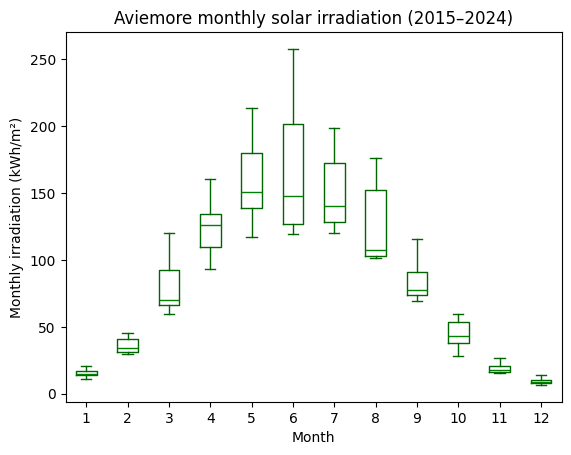

/tmp/ipython-input-3235/3727511234.py:307: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rain_month_arrays, labels=list(months)[:len(rain_month_arrays)], showfliers=False,


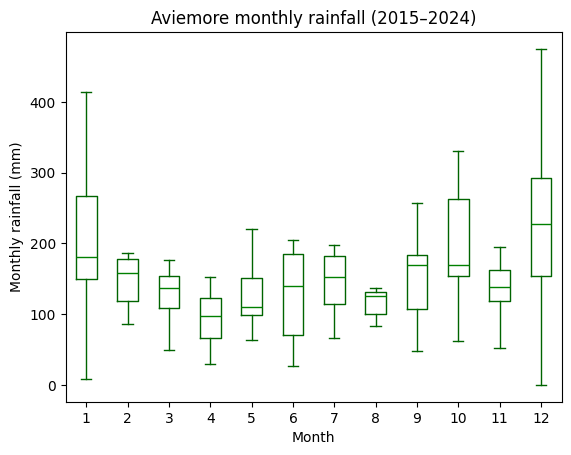

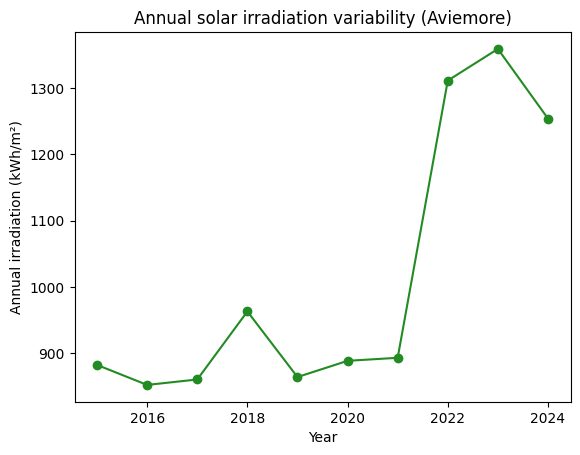

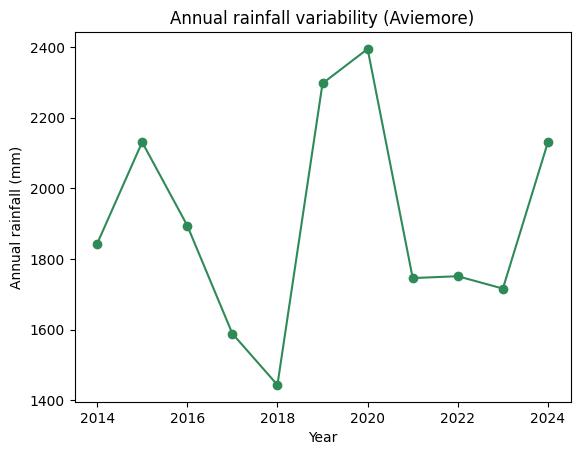

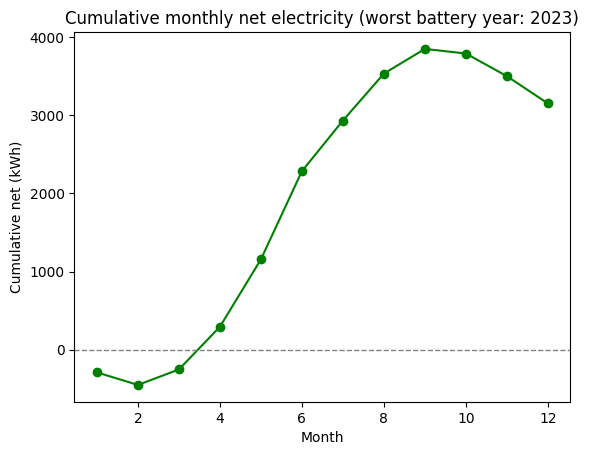

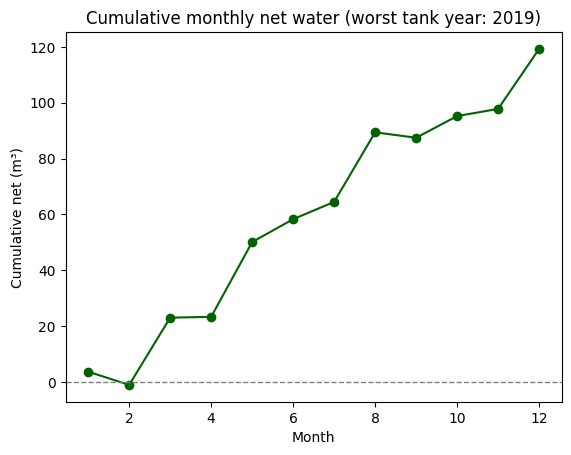

,Metric,Value
0,PV area sized to worst solar year,40 m²
1,Recommended minimum battery capacity (worst year),4350 kWh
2,Rain catchment area sized to driest year,139 m²
3,Recommended minimum tank capacity (worst year),125 m³


In [9]:
# CP540 Assessment 2 (Aviemore, MIDAS Open) — Solar + Rain self-sufficiency
# Data: hourly rainfall + hourly solar irradiation (global) for 2015–2024

import pandas as pd
import numpy as np
import glob
from pathlib import Path
import matplotlib.pyplot as plt

# -------------------------
# 1) FILE PATHS
# -------------------------

rain_files = sorted(glob.glob("/content/midas-open_uk-hourly-rain-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_20*.csv"))
rad_files  = sorted(glob.glob("/content/midas-open_uk-radiation-obs_dv-202507_inverness-shire_00113_aviemore_qcv-1_20*.csv"))

if len(rain_files) > 0:
    print("Rain files:", len(rain_files), rain_files[0], "…", rain_files[-1])

if len(rad_files) > 0:
    print("Rad  files:", len(rad_files),  rad_files[0],  "…", rad_files[-1])

# -------------------------
# 2) MIDAS “BADC-CSV” READER
# -------------------------
def read_midas_badc_csv(filepath: str) -> pd.DataFrame:

    data_line = None
    with open(filepath, "r", errors="ignore") as f:
        for i, line in enumerate(f):
            if line.strip() == "data":
                data_line = i
                break
    if data_line is None:
        raise ValueError(f"No 'data' marker found in: {filepath}")

    df = pd.read_csv(filepath, skiprows=data_line + 1, na_values=["NA"])
    return df

# -------------------------
# 3) LOAD + CLEAN RAIN
# -------------------------
def load_rain(files) -> pd.DataFrame:
    frames = []
    for fp in files:
        try:
            df = read_midas_badc_csv(fp)

            # Parse time; drop non-time footer rows if any (some MIDAS exports contain trailing text)
            df["ob_end_time"] = pd.to_datetime(df["ob_end_time"], errors="coerce")
            df["prcp_amt"]    = pd.to_numeric(df["prcp_amt"], errors="coerce")

            df = df.dropna(subset=["ob_end_time"])  # remove footer / bad rows
            frames.append(df[["ob_end_time", "prcp_amt"]])
        except Exception as e:
            print(f"Error loading {fp}: {e}")
            continue

    if not frames:
        # Return an empty DataFrame with expected columns if no data was loaded
        return pd.DataFrame(columns=["ob_end_time", "prcp_amt"])

    out = pd.concat(frames, ignore_index=True).sort_values("ob_end_time")
    return out

if len(rain_files) > 0:
    rain = load_rain(rain_files)
    if not rain.empty:
        print("Rain rows:", rain.shape, "time:", rain["ob_end_time"].min(), "→", rain["ob_end_time"].max())
        print("Rain missing fraction (prcp_amt):", rain["prcp_amt"].isna().mean())

rain = pd.DataFrame(columns=["ob_end_time", "prcp_amt"]) if 'rain' not in locals() or rain.empty else rain

# -------------------------
# 4) LOAD + CLEAN RADIATION
# -------------------------
def load_rad(files) -> pd.DataFrame:
    frames = []
    for fp in files:
        try:
            df = read_midas_badc_csv(fp)

            df["ob_end_time"]    = pd.to_datetime(df["ob_end_time"], errors="coerce")
            df["glbl_irad_amt"]  = pd.to_numeric(df["glbl_irad_amt"], errors="coerce")  # KJ/m2

            df = df.dropna(subset=["ob_end_time"])
            frames.append(df[["ob_end_time", "glbl_irad_amt"]])
        except Exception as e:
            print(f"Error loading {fp}: {e}")
            continue

    if not frames:
        # Return an empty DataFrame with expected columns if no data was loaded
        return pd.DataFrame(columns=["ob_end_time", "glbl_irad_amt"])

    out = pd.concat(frames, ignore_index=True).sort_values("ob_end_time")
    return out

if len(rad_files) > 0:
    rad = load_rad(rad_files)
    if not rad.empty:
        print("Rad rows:", rad.shape, "time:", rad["ob_end_time"].min(), "→", rad["ob_end_time"].max())
        print("Rad missing fraction (glbl_irad_amt):", rad["glbl_irad_amt"].isna().mean())
    else:
        print("Radiation data frame is empty after loading. No valid radiation data.")
rad = pd.DataFrame(columns=["ob_end_time", "glbl_irad_amt"]) if 'rad' not in locals() or rad.empty else rad

# -------------------------
# 5) AGGREGATE TO HOURLY, MONTHLY, ANNUAL
# -------------------------
# Radiation sometimes has end times at xx:59 (seen in MIDAS); flooring to hour avoids split bins.
rad2 = pd.DataFrame(columns=['time', 'glbl_irad_amt', 'kwh_m2'])
if not rad.empty and 'ob_end_time' in rad.columns and 'glbl_irad_amt' in rad.columns:
    rad2 = rad.copy()
    rad2["time"] = rad2["ob_end_time"].dt.floor("h")
    rad2 = rad2.drop(columns=["ob_end_time"])
    rad2 = rad2.groupby("time", as_index=False)["glbl_irad_amt"].mean()
    rad2["kwh_m2"] = rad2["glbl_irad_amt"] / 3600.0

rain2 = pd.DataFrame(columns=['time', 'prcp_amt'])
if not rain.empty and 'ob_end_time' in rain.columns and 'prcp_amt' in rain.columns:
    rain2 = rain.copy()
    rain2["time"] = rain2["ob_end_time"].dt.floor("h")
    rain2 = rain2.drop(columns=["ob_end_time"])
    rain2 = rain2.groupby("time", as_index=False)["prcp_amt"].sum()

for df_var in (rad2, rain2):
    if not df_var.empty and 'time' in df_var.columns:
        df_var["year"]  = df_var["time"].dt.year
        df_var["month"] = df_var["time"].dt.month
    else:
        # Ensure 'year' and 'month' columns exist even if empty, to prevent KeyError later
        if 'year' not in df_var.columns:
            df_var['year'] = pd.Series(dtype='int')
        if 'month' not in df_var.columns:
            df_var['month'] = pd.Series(dtype='int')

monthly_rad = pd.DataFrame(columns=["year", "month", "kwh_m2"])
if not rad2.empty and "year" in rad2.columns and "month" in rad2.columns and "kwh_m2" in rad2.columns:
    monthly_rad = rad2.groupby(["year", "month"], as_index=False)["kwh_m2"].sum()

monthly_rain = pd.DataFrame(columns=["year", "month", "prcp_amt"])
if not rain2.empty and "year" in rain2.columns and "month" in rain2.columns and "prcp_amt" in rain2.columns:
    monthly_rain = rain2.groupby(["year", "month"], as_index=False)["prcp_amt"].sum()

annual_rad = pd.DataFrame(columns=["year", "kwh_m2"])
if not monthly_rad.empty and "year" in monthly_rad.columns and "kwh_m2" in monthly_rad.columns:
    annual_rad = monthly_rad.groupby("year", as_index=False)["kwh_m2"].sum()

annual_rain = pd.DataFrame(columns=["year", "prcp_amt"])
if not monthly_rain.empty and "year" in monthly_rain.columns and "prcp_amt" in monthly_rain.columns:
    annual_rain = monthly_rain.groupby("year", as_index=False)["prcp_amt"].sum()

print("\nAnnual irradiation (kWh/m2):")
display(annual_rad)

print("\nAnnual rainfall (mm):")
display(annual_rain)

# -------------------------
# 6) SYSTEM SIZING ASSUMPTIONS
# -------------------------
E_elec_year = 5000.0     # kWh/year household electricity demand
V_water_year = 200.0     # m3/year household water demand
eta_pv = 0.15            # PV conversion efficiency
runoff = 1            # roof runoff coefficient Assumed to be one

# -------------------------
# 7) SOLAR PANEL AREA (YEAR-TO-YEAR VARIATION)
# -------------------------
A_pv_rounded = 0 # Initialize with a default value
if not annual_rad.empty and "kwh_m2" in annual_rad.columns and not annual_rad["kwh_m2"].eq(0).all():
    annual_rad["elec_kwh_per_m2"] = annual_rad["kwh_m2"] * eta_pv
    # Handle potential division by zero or very small numbers, resulting in inf
    annual_rad["panel_area_m2"]   = E_elec_year / annual_rad["elec_kwh_per_m2"]
    annual_rad.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Recommend sizing based on worst (lowest irradiation) year
    if not annual_rad["panel_area_m2"].dropna().empty:
        worst_solar = annual_rad.loc[annual_rad["panel_area_m2"].idxmax()]

        print("\nSolar sizing:")
        print("Mean panel area (m2):".ljust(30), annual_rad["panel_area_m2"].mean())
        print("Worst-year panel area (m2):".ljust(30), float(worst_solar["panel_area_m2"]), "in year", int(worst_solar["year"]))

        A_pv = float(worst_solar["panel_area_m2"])  # adopt worst-year design area
        A_pv_rounded = np.ceil(A_pv)                # practical rounding to whole m2
        print("Adopted PV area (rounded up):".ljust(30), A_pv_rounded, "m2")

# -------------------------
# 8) ELECTRICITY STORAGE (SEASONAL)
# -------------------------
monthly = pd.DataFrame(columns=["year", "month", "pv_gen_kwh", "demand_kwh", "net_kwh"])
if not monthly_rad.empty and not monthly_rain.empty:
    monthly = monthly_rad.merge(monthly_rain, on=["year", "month"], how="inner")
    if not monthly.empty:
        monthly["pv_gen_kwh"] = monthly["kwh_m2"] * eta_pv * A_pv_rounded
        monthly["demand_kwh"] = E_elec_year / 12.0
        monthly["net_kwh"]    = monthly["pv_gen_kwh"] - monthly["demand_kwh"]

def min_storage_capacity(net_monthly: pd.Series) -> float:
    if net_monthly.empty:
        return 0.0
    cum = net_monthly.cumsum()
    return float(cum.max() - cum.min())

battery_by_year = pd.DataFrame(columns=["year", "battery_kwh_min"])
if not monthly.empty and 'net_kwh' in monthly.columns:
    batt_data = []
    for y, dfy in monthly.sort_values(["year", "month"]).groupby("year"):
        if not dfy['net_kwh'].empty:
            # Use the new min_storage_capacity function
            C = min_storage_capacity(dfy["net_kwh"])
            batt_data.append((y, C))
    if batt_data:
        battery_by_year = pd.DataFrame(batt_data, columns=["year", "battery_kwh_min"])
        print("\nBattery capacity requirement by year (kWh):") # Updated print statement
        display(battery_by_year)

battery_recommended = 0.0 # Default value
if not battery_by_year.empty and "battery_kwh_min" in battery_by_year.columns:
    battery_recommended = battery_by_year["battery_kwh_min"].max()
    print("Recommended minimum battery capacity (worst year):".ljust(50), battery_recommended, "kWh") # Updated print statement
    print("Practical rounded recommendation:".ljust(50), np.ceil(battery_recommended/50)*50, "kWh (round to 50 kWh blocks)")


# -------------------------
# 9) RAINWATER COLLECTION AREA (YEAR-TO-YEAR VARIATION)
# -------------------------
A_roof_rounded = 0 # Initialize with a default value
if not annual_rain.empty and "prcp_amt" in annual_rain.columns and not annual_rain["prcp_amt"].eq(0).all():
    annual_rain["m3_per_m2_year"] = annual_rain["prcp_amt"] * 0.001 * runoff
    # Handle potential division by zero or very small numbers, resulting in inf
    annual_rain["roof_area_m2"]   = V_water_year / annual_rain["m3_per_m2_year"]
    annual_rain.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Recommend sizing based on worst (lowest irradiation) year
    if not annual_rain["roof_area_m2"].dropna().empty:
        worst_rain = annual_rain.loc[annual_rain["roof_area_m2"].idxmax()]
        print("\nRainwater sizing:")
        print("Mean roof area (m2):".ljust(30), annual_rain["roof_area_m2"].mean())
        print("Worst-year roof area (m2):".ljust(30), float(worst_rain["roof_area_m2"]), "in year", int(worst_rain["year"]))

        A_roof = float(worst_rain["roof_area_m2"])
        A_roof_rounded = np.ceil(A_roof)
        print("Adopted collection area (rounded up):".ljust(30), A_roof_rounded, "m2")

# -------------------------
# 10) WATER STORAGE (SEASONAL)
# -------------------------

required_cols_monthly_water = ["year", "month", "prcp_amt", "water_collected_m3", "water_demand_m3", "net_water_m3"]
for col in required_cols_monthly_water:
    if col not in monthly.columns:
        monthly[col] = pd.Series(dtype='float')

if not monthly.empty and 'prcp_amt' in monthly.columns:
    monthly["water_collected_m3"] = monthly["prcp_amt"] * 0.001 * A_roof_rounded * runoff
    monthly["water_demand_m3"]    = V_water_year / 12.0
    monthly["net_water_m3"]       = monthly["water_collected_m3"] - monthly["water_demand_m3"]

tank_by_year = pd.DataFrame(columns=["year", "tank_m3_min"])
if not monthly.empty and 'net_water_m3' in monthly.columns:
    tank_data = []
    for y, dfy in monthly.sort_values(["year", "month"]).groupby("year"):
        if not dfy['net_water_m3'].empty: # Added a colon here
            # Use the new min_storage_capacity function
            Cw = min_storage_capacity(dfy["net_water_m3"])
            tank_data.append((y, Cw))
    if tank_data:
        tank_by_year = pd.DataFrame(tank_data, columns=["year", "tank_m3_min"])
        print("\nTank capacity requirement by year (m3):")
        display(tank_by_year)

tank_recommended = 0.0 # Default value
if not tank_by_year.empty and "tank_m3_min" in tank_by_year.columns:
    tank_recommended = tank_by_year["tank_m3_min"].max()
    print("Recommended minimum tank capacity (worst year):".ljust(50), tank_recommended, "m3")
    print("Practical rounded recommendation:".ljust(50), np.ceil(tank_recommended/5)*5, "m3 (round to 5 m3 blocks)")

# -------------------------
# 11) FIGURES FOR SLIDES
# -------------------------
# A) Monthly irradiation distribution across years
months = range(1, 13)
if not monthly_rad.empty and "month" in monthly_rad.columns and "kwh_m2" in monthly_rad.columns:
    rad_month_arrays = [monthly_rad.loc[monthly_rad["month"]==m, "kwh_m2"].values for m in months]
    rad_month_arrays = [arr for arr in rad_month_arrays if arr.size > 0] # Filter out empty arrays

    if rad_month_arrays:
        plt.figure()
        plt.boxplot(rad_month_arrays, labels=list(months)[:len(rad_month_arrays)], showfliers=False,
                    boxprops=dict(color='darkgreen'), medianprops=dict(color='green'),
                    whiskerprops=dict(color='darkgreen'), capprops=dict(color='darkgreen'))
        plt.xlabel("Month")
        plt.ylabel("Monthly irradiation (kWh/m²)")
        plt.title("Aviemore monthly solar irradiation (2015–2024)")
        plt.show()

# B) Monthly rainfall distribution across years
if not monthly_rain.empty and "month" in monthly_rain.columns and "prcp_amt" in monthly_rain.columns:
    rain_month_arrays = [monthly_rain.loc[monthly_rain["month"]==m, "prcp_amt"].values for m in months]
    rain_month_arrays = [arr for arr in rain_month_arrays if arr.size > 0] # Filter out empty arrays

    if rain_month_arrays:
        plt.figure()
        plt.boxplot(rain_month_arrays, labels=list(months)[:len(rain_month_arrays)], showfliers=False,
                    boxprops=dict(color='darkgreen'), medianprops=dict(color='green'),
                    whiskerprops=dict(color='darkgreen'), capprops=dict(color='darkgreen'))
        plt.xlabel("Month")
        plt.ylabel("Monthly rainfall (mm)")
        plt.title("Aviemore monthly rainfall (2015–2024)")
        plt.show()


# C) Annual variability plots
if not annual_rad.empty and "year" in annual_rad.columns and "kwh_m2" in annual_rad.columns:
    plt.figure()
    plt.plot(annual_rad["year"], annual_rad["kwh_m2"], marker="o", color='forestgreen')
    plt.xlabel("Year")
    plt.ylabel("Annual irradiation (kWh/m²)")
    plt.title("Annual solar irradiation variability (Aviemore)")
    plt.show()

if not annual_rain.empty and "year" in annual_rain.columns and "prcp_amt" in annual_rain.columns:
    plt.figure()
    plt.plot(annual_rain["year"], annual_rain["prcp_amt"], marker="o", color='seagreen')
    plt.xlabel("Year")
    plt.ylabel("Annual rainfall (mm)")
    plt.title("Annual rainfall variability (Aviemore)")
    plt.show()

# D) Example worst-year seasonal storage curves (electricity + water)
worst_batt_year = None
if not battery_by_year.empty and "battery_kwh_min" in battery_by_year.columns:
    worst_batt_year = int(battery_by_year.loc[battery_by_year["battery_kwh_min"].idxmax(), "year"])

worst_tank_year = None
if not tank_by_year.empty and "tank_m3_min" in tank_by_year.columns:
    worst_tank_year = int(tank_by_year.loc[tank_by_year["tank_m3_min"].idxmax(), "year"])

def plot_cumulative_balance(df, value_col, title, ylab, plot_color='green'):
    if df.empty or value_col not in df.columns or df[value_col].isnull().all():
       return
    d = df.sort_values(["month"]).copy()
    d["cum"] = d[value_col].cumsum()
    plt.figure()
    plt.plot(d["month"], d["cum"], marker="o", color=plot_color)
    plt.xlabel("Month")
    plt.ylabel(ylab)
    plt.title(title)
    plt.axhline(0, linewidth=1, color='gray', linestyle='--')
    plt.show()

if worst_batt_year is not None and not monthly.empty and "year" in monthly.columns and "net_kwh" in monthly.columns:
    plot_cumulative_balance(monthly[monthly["year"]==worst_batt_year], "net_kwh",
                            f"Cumulative monthly net electricity (worst battery year: {worst_batt_year})",
                            "Cumulative net (kWh)", plot_color='green')

if worst_tank_year is not None and not monthly.empty and "year" in monthly.columns and "net_water_m3" in monthly.columns:
    plot_cumulative_balance(monthly[monthly["year"]==worst_tank_year], "net_water_m3",
                            f"Cumulative monthly net water (worst tank year: {worst_tank_year})",
                            "Cumulative net (m³)", plot_color='darkgreen')

# E) Summary table
summary = pd.DataFrame({
    "Metric": [
        "PV area sized to worst solar year",
        "Recommended minimum battery capacity (worst year)",
        "Rain catchment area sized to driest year",
        "Recommended minimum tank capacity (worst year)"
    ],
    "Value": [
        f"{A_pv_rounded:.0f} m²" if A_pv_rounded is not np.inf else "N/A",
        f"{np.ceil(battery_recommended/50)*50:.0f} kWh",
        f"{A_roof_rounded:.0f} m²" if A_roof_rounded is not np.inf else "N/A",
        f"{np.ceil(tank_recommended/5)*5:.0f} m³"
    ]
})
display(summary)

# Task
Execute all cells.

## Execute all cells

### Subtask:
Execute all cells in the notebook sequentially.


## Summary:

The provided solving process describes the execution of all cells in the notebook. As this step focuses solely on execution, there are no analytical findings or insights to report at this stage.
